<a href="https://colab.research.google.com/github/Mittssyymaniac/Language_Traslation/blob/main/34.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AND OR NOR

In [ ]:
# AND Gate
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
threshold = 2
print("AND Gate")
for i in range(4):
    y = x1[i] + x2[i]
    output = 1 if y >= threshold else 0
    print(f"{x1[i]} {x2[i]} => {output}")

# OR Gate
threshold = 1
print("\nOR Gate")
for i in range(4):
    y = x1[i] + x2[i]
    output = 1 if y >= threshold else 0
    print(f"{x1[i]} {x2[i]} => {output}")

# NOR Gate
threshold = -1
print("\nNOR Gate")
for i in range(4):
    y = -x1[i] - x2[i]
    output = 1 if y >= threshold else 0
    print(f"{x1[i]} {x2[i]} => {output}")


Activation functions

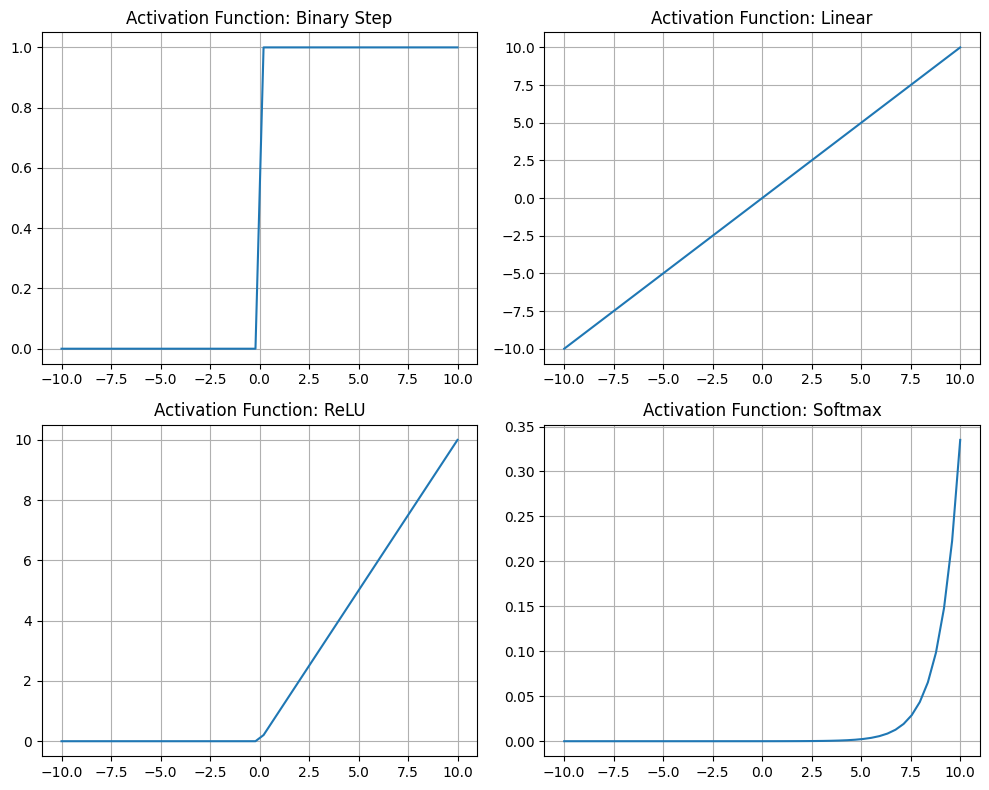

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10)

# Activation functions
def binary_step(x): return np.heaviside(x, 1)
def linear(x): return x
def relu(x): return np.maximum(0, x)
def softmax(x): return np.exp(x) / np.sum(np.exp(x))  # Softmax over vector

# Plotting all activation functions
activations = {
    "Binary Step": binary_step,
    "Linear": linear,
    "ReLU": relu,
    "Softmax": softmax
}

plt.figure(figsize=(10, 8))
for i, (name, func) in enumerate(activations.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(x, func(x))
    plt.title(f"Activation Function: {name}")
    plt.grid(True)
plt.tight_layout()
plt.show()


Hebbian

In [3]:
import numpy as np

X = np.array([[1, 1], [1, -1], [-1, 1], [-1, -1]])
Y = np.array([1, -1, -1, -1])
weights = np.zeros(2)
lr = 1

for i in range(len(X)):
    weights += lr * X[i] * Y[i]

print("Final weights:", weights)


Final weights: [2. 2.]


Perceptron

In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0, 0, 0, 1])
weights = np.zeros(2)
bias = 0
lr = 1

for _ in range(10):
    for i in range(len(X)):
        y_pred = 1 if np.dot(X[i], weights) + bias >= 0 else 0
        error = Y[i] - y_pred
        weights += lr * error * X[i]
        bias += lr * error

print("Trained weights:", weights)
print("Bias:", bias)


Delta

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])
weights = np.random.rand(2, 1)
bias = np.random.rand(1)
lr = 0.1

for _ in range(10000):
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)
    error = Y - y_pred
    weights += lr * np.dot(X.T, error * sigmoid_deriv(y_pred))
    bias += lr * np.sum(error * sigmoid_deriv(y_pred))

print("Final weights:", weights)
print("Final bias:", bias)


SDPTA

In [ ]:
import numpy as np

# Input and expected output for AND gate
X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([0, 0, 0, 1])  # AND gate output

# Initialize weights and bias
weights = np.zeros(2)
bias = 0
lr = 1  # learning rate
epochs = 10

def step_function(y):
    return 1 if y >= 0 else 0

# Training loop
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    for i in range(len(X)):
        y_in = np.dot(X[i], weights) + bias
        y_pred = step_function(y_in)
        error = Y[i] - y_pred
        weights += lr * error * X[i]
        bias += lr * error
        print(f"Input: {X[i]}, Predicted: {y_pred}, Error: {error}, Weights: {weights}, Bias: {bias}")

print("\nFinal Weights:", weights)
print("Final Bias:", bias)


SCPTA

In [ ]:
import numpy as np

# Input and output for XOR-like pattern (not perfectly separable)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [0]])  # Trying to learn XOR (continuous won't fully succeed)

# Initialize weights and bias
weights = np.random.rand(2, 1)
bias = np.random.rand(1)
lr = 0.1
epochs = 10000

# Activation function and derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training loop
for _ in range(epochs):
    # Forward pass
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)

    # Error and backpropagation
    error = Y - y_pred
    gradient = error * sigmoid_derivative(y_pred)

    # Update weights and bias
    weights += lr * np.dot(X.T, gradient)
    bias += lr * np.sum(gradient)

print("Final Weights:\n", weights)
print("Final Bias:\n", bias)


RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import numpy as np

X = np.random.random((100, 10, 1))  # 100 samples, 10 time steps, 1 feature
y = np.random.randint(2, size=(100, 1))

model = Sequential([
    SimpleRNN(16, input_shape=(10, 1)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=10)


CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and normalize CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Plot 25 sample images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i]); plt.xticks([]); plt.yticks([])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
])

# Compile, train, evaluate
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.ylim([0.5, 1])
plt.legend(); plt.show()


Perceptron Classifier for Iris Dataset

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report
import numpy as np
import random

X, y = load_iris(return_X_y=True)
y = (y == 0).astype(int)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Perceptron(max_iter=10, tol=0.001, random_state=42)
model.fit(X_train, y_train)


for i in random.sample(range(len(X_train)), 10):
    print(i, model.predict([X_train[i]]))
print(classification_report(model.predict(X_test), y_test))


107 [0]
65 [0]
85 [0]
43 [0]
96 [0]
118 [0]
50 [0]
69 [0]
102 [1]
54 [0]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



MLP Classifier on Breast Cancer Data

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



perceptron model using tensorflow and keras

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and normalize data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=2000, validation_split=0.2)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")
